In [1]:
# ============================================================
# CELL 1: Imports & Config
# ============================================================
import os, warnings
import numpy as np
import pandas as pd
import joblib
from pathlib import Path

warnings.filterwarnings("ignore")

OUTPUT_DIR = Path("/kaggle/working/unsw_v2")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

LABEL_COL   = "Label"
ATTACK_COL  = "Attack"
CORR_THRESH = 0.95
VAR_THRESH  = 0.01
RANDOM_SEED = 42

In [2]:
# ============================================================
# CELL 2: Load
# ============================================================
df_raw = pd.read_parquet("/kaggle/input/datasets/dhoogla/nfunswnb15v2/NF-UNSW-NB15-V2.parquet")
print(f"Shape: {df_raw.shape}")
print(f"Attack oranı: {df_raw[LABEL_COL].mean():.3%}")

Shape: (1986745, 43)
Attack oranı: 3.779%


In [3]:
# ============================================================
# CELL 3: Split Features / Labels
# ============================================================
from sklearn.model_selection import train_test_split

X = df_raw.drop(columns=[LABEL_COL, ATTACK_COL])
y = df_raw[LABEL_COL].astype(int)
attack_cat = df_raw[ATTACK_COL].copy()

X_train_raw, X_test_raw, y_train, y_test, cat_train, cat_test = train_test_split(
    X, y, attack_cat,
    test_size=0.2, random_state=RANDOM_SEED, stratify=y
)

# Index sıfırla
for s in [X_train_raw, X_test_raw, y_train, y_test, cat_train, cat_test]:
    s.reset_index(drop=True, inplace=True)

print(f"Train: {X_train_raw.shape} | Normal: {(y_train==0).sum()} | Attack: {(y_train==1).sum()}")
print(f"Test:  {X_test_raw.shape}")

Train: (1589396, 41) | Normal: 1529333 | Attack: 60063
Test:  (397349, 41)


In [4]:
# ============================================================
# CELL 4: Preprocessing — SADECE normal train üzerinden fit
# ============================================================
from sklearn.preprocessing import MinMaxScaler

X_train_normal = X_train_raw[y_train == 0].copy()

# 4a. Inf/NaN → medyan (normal trafikten)
X_train_normal.replace([np.inf, -np.inf], np.nan, inplace=True)
col_medians = X_train_normal.median()

for df_part in [X_train_normal, X_train_raw, X_test_raw]:
    df_part.replace([np.inf, -np.inf], np.nan, inplace=True)
    df_part.fillna(col_medians, inplace=True)

# 4b. Varyans filtresi
var_mask  = X_train_normal.var() > VAR_THRESH
X_train_normal = X_train_normal.loc[:, var_mask]
print(f"Varyans sonrası: {var_mask.sum()} feature")

# 4c. Korelasyon filtresi
corr_matrix = X_train_normal.corr().abs()
upper       = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
drop_corr   = [c for c in upper.columns if any(upper[c] > CORR_THRESH)]
keep_cols   = [c for c in X_train_normal.columns if c not in drop_corr]
print(f"Korelasyon sonrası: {len(drop_corr)} atıldı → {len(keep_cols)} feature kaldı")
print(f"Kalan feature'lar: {keep_cols}")

# 4d. MinMaxScaler — SADECE normal train'e fit
scaler = MinMaxScaler()
X_train_scaled     = scaler.fit_transform(X_train_raw[y_train == 0][keep_cols])
X_train_all_scaled = scaler.transform(X_train_raw[keep_cols])
X_test_scaled      = scaler.transform(X_test_raw[keep_cols])

INPUT_DIM = X_train_scaled.shape[1]
print(f"\n✅ Final INPUT_DIM: {INPUT_DIM}")
print(f"   Train normal: {X_train_scaled.shape}")
print(f"   Train all:    {X_train_all_scaled.shape}")
print(f"   Test:         {X_test_scaled.shape}")

Varyans sonrası: 41 feature
Korelasyon sonrası: 10 atıldı → 31 feature kaldı
Kalan feature'lar: ['L4_SRC_PORT', 'L4_DST_PORT', 'PROTOCOL', 'L7_PROTO', 'IN_BYTES', 'IN_PKTS', 'OUT_BYTES', 'TCP_FLAGS', 'FLOW_DURATION_MILLISECONDS', 'DURATION_IN', 'DURATION_OUT', 'MIN_TTL', 'LONGEST_FLOW_PKT', 'SHORTEST_FLOW_PKT', 'MIN_IP_PKT_LEN', 'SRC_TO_DST_SECOND_BYTES', 'DST_TO_SRC_SECOND_BYTES', 'RETRANSMITTED_IN_PKTS', 'SRC_TO_DST_AVG_THROUGHPUT', 'DST_TO_SRC_AVG_THROUGHPUT', 'NUM_PKTS_UP_TO_128_BYTES', 'NUM_PKTS_128_TO_256_BYTES', 'NUM_PKTS_256_TO_512_BYTES', 'NUM_PKTS_512_TO_1024_BYTES', 'TCP_WIN_MAX_IN', 'TCP_WIN_MAX_OUT', 'ICMP_TYPE', 'DNS_QUERY_ID', 'DNS_QUERY_TYPE', 'DNS_TTL_ANSWER', 'FTP_COMMAND_RET_CODE']

✅ Final INPUT_DIM: 31
   Train normal: (1529333, 31)
   Train all:    (1589396, 31)
   Test:         (397349, 31)


In [5]:
# ============================================================
# CELL 5: Kaydet
# ============================================================
np.save(OUTPUT_DIR / "X_train_normal.npy",  X_train_scaled)
np.save(OUTPUT_DIR / "X_train_all.npy",     X_train_all_scaled)
np.save(OUTPUT_DIR / "X_test.npy",          X_test_scaled)
np.save(OUTPUT_DIR / "y_train.npy",         y_train.values)
np.save(OUTPUT_DIR / "y_test.npy",          y_test.values)
np.save(OUTPUT_DIR / "cat_test.npy",        cat_test.values)
joblib.dump(scaler,    OUTPUT_DIR / "scaler_unsw.pkl")
joblib.dump(keep_cols, OUTPUT_DIR / "keep_cols_unsw.pkl")

print("✅ Preprocessing tamam")
print(f"   Kaydedilen dosyalar: {list(OUTPUT_DIR.iterdir())}")

✅ Preprocessing tamam
   Kaydedilen dosyalar: [PosixPath('/kaggle/working/unsw_v2/keep_cols_unsw.pkl'), PosixPath('/kaggle/working/unsw_v2/y_test.npy'), PosixPath('/kaggle/working/unsw_v2/cat_test.npy'), PosixPath('/kaggle/working/unsw_v2/X_train_normal.npy'), PosixPath('/kaggle/working/unsw_v2/X_test.npy'), PosixPath('/kaggle/working/unsw_v2/scaler_unsw.pkl'), PosixPath('/kaggle/working/unsw_v2/X_train_all.npy'), PosixPath('/kaggle/working/unsw_v2/y_train.npy')]


In [6]:
# ============================================================
# CELL 6: Model Tanımları
# ============================================================
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

class DeepAutoencoder(nn.Module):
    def __init__(self, input_dim: int, latent_dim: int = 8):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128), nn.ReLU(), nn.BatchNorm1d(128),
            nn.Linear(128, 64),        nn.ReLU(), nn.BatchNorm1d(64),
            nn.Linear(64, 32),         nn.ReLU(),
            nn.Linear(32, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 32),  nn.ReLU(),
            nn.Linear(32, 64),          nn.ReLU(), nn.BatchNorm1d(64),
            nn.Linear(64, 128),         nn.ReLU(), nn.BatchNorm1d(128),
            nn.Linear(128, input_dim),  nn.Sigmoid()
        )
    def forward(self, x):
        return self.decoder(self.encoder(x))
    def reconstruction_error(self, x):
        self.eval()
        with torch.no_grad():
            return torch.mean((x - self.forward(x)) ** 2, dim=1).cpu().numpy()


class DenoisingAutoencoder(nn.Module):
    def __init__(self, input_dim: int, latent_dim: int = 8, noise_std: float = 0.05):
        super().__init__()
        self.noise_std = noise_std
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128), nn.ReLU(), nn.BatchNorm1d(128),
            nn.Linear(128, 64),        nn.ReLU(), nn.BatchNorm1d(64),
            nn.Linear(64, 32),         nn.ReLU(),
            nn.Linear(32, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 32),  nn.ReLU(),
            nn.Linear(32, 64),          nn.ReLU(), nn.BatchNorm1d(64),
            nn.Linear(64, 128),         nn.ReLU(), nn.BatchNorm1d(128),
            nn.Linear(128, input_dim),  nn.Sigmoid()
        )
    def forward(self, x, add_noise=False):
        if add_noise and self.training:
            noise = torch.randn_like(x) * self.noise_std
            x = torch.clamp(x + noise, 0.0, 1.0)
        return self.decoder(self.encoder(x))
    def reconstruction_error(self, x):
        self.eval()
        with torch.no_grad():
            return torch.mean((x - self.forward(x, add_noise=False)) ** 2, dim=1).cpu().numpy()

Device: cuda


In [7]:
# ============================================================
# CELL 7: Eğitim Fonksiyonu
# ============================================================
import numpy as np
from pathlib import Path

OUTPUT_DIR = Path("/kaggle/working/unsw_v2")

def train_model(model, X_train_np, epochs=50, batch_size=1024, lr=1e-3,
                is_dae=False, model_name="ae"):
    X_tensor = torch.tensor(X_train_np, dtype=torch.float32)
    loader   = DataLoader(TensorDataset(X_tensor), batch_size=batch_size, shuffle=True)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=5
    )
    criterion = nn.MSELoss()
    model.to(DEVICE)

    history = []
    for epoch in range(1, epochs + 1):
        model.train()
        epoch_loss = 0.0
        for (batch,) in loader:
            batch = batch.to(DEVICE)
            recon = model(batch, add_noise=True) if is_dae else model(batch)
            loss  = criterion(recon, batch)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * len(batch)

        avg_loss = epoch_loss / len(X_tensor)
        scheduler.step(avg_loss)
        history.append(avg_loss)

        if epoch % 10 == 0 or epoch == 1:
            print(f"  [{model_name}] Epoch {epoch:3d}/{epochs} | Loss: {avg_loss:.6f} | LR: {optimizer.param_groups[0]['lr']:.2e}")

    torch.save(model.state_dict(), OUTPUT_DIR / f"{model_name}_weights.pt")
    np.save(OUTPUT_DIR / f"{model_name}_history.npy", np.array(history))
    print(f"  ✅ {model_name} kaydedildi")
    return history

In [8]:
# ============================================================
# CELL 8: Eğit — Vanilla AE
# ============================================================
X_train_normal = np.load(OUTPUT_DIR / "X_train_normal.npy")
INPUT_DIM = X_train_normal.shape[1]   # 31

print(f"=== Vanilla AE (INPUT_DIM={INPUT_DIM}) ===")
ae_model  = DeepAutoencoder(input_dim=INPUT_DIM, latent_dim=8)
ae_history = train_model(ae_model, X_train_normal, epochs=50,
                         is_dae=False, model_name="unsw_ae")

=== Vanilla AE (INPUT_DIM=31) ===
  [unsw_ae] Epoch   1/50 | Loss: 0.010871 | LR: 1.00e-03
  [unsw_ae] Epoch  10/50 | Loss: 0.000051 | LR: 1.00e-03
  [unsw_ae] Epoch  20/50 | Loss: 0.000032 | LR: 1.00e-03
  [unsw_ae] Epoch  30/50 | Loss: 0.000022 | LR: 1.00e-03
  [unsw_ae] Epoch  40/50 | Loss: 0.000018 | LR: 1.00e-03
  [unsw_ae] Epoch  50/50 | Loss: 0.000015 | LR: 1.00e-03
  ✅ unsw_ae kaydedildi


In [9]:
# ============================================================
# CELL 9: Eğit — Denoising AE
# ============================================================
print(f"=== Denoising AE (INPUT_DIM={INPUT_DIM}) ===")
dae_model   = DenoisingAutoencoder(input_dim=INPUT_DIM, latent_dim=8, noise_std=0.05)
dae_history = train_model(dae_model, X_train_normal, epochs=50,
                          is_dae=True, model_name="unsw_dae")

=== Denoising AE (INPUT_DIM=31) ===
  [unsw_dae] Epoch   1/50 | Loss: 0.009861 | LR: 1.00e-03
  [unsw_dae] Epoch  10/50 | Loss: 0.000230 | LR: 1.00e-03
  [unsw_dae] Epoch  20/50 | Loss: 0.000202 | LR: 1.00e-03
  [unsw_dae] Epoch  30/50 | Loss: 0.000198 | LR: 1.00e-03
  [unsw_dae] Epoch  40/50 | Loss: 0.000185 | LR: 1.00e-03
  [unsw_dae] Epoch  50/50 | Loss: 0.000180 | LR: 1.00e-03
  ✅ unsw_dae kaydedildi


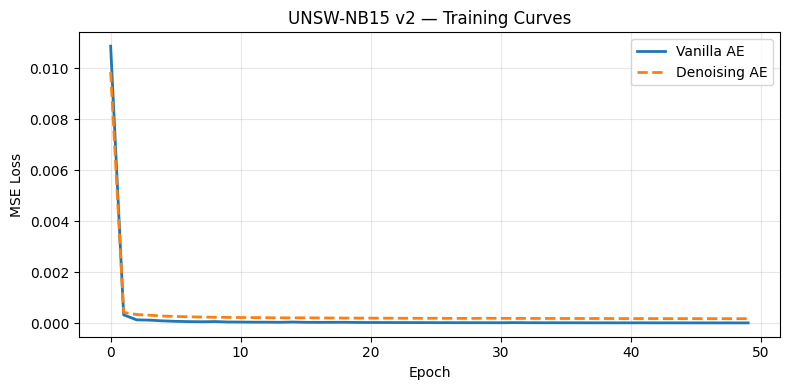

✅ training_curve_unsw.png kaydedildi


In [10]:
# ============================================================
# CELL 10: Training Curve Grafiği
# ============================================================
import matplotlib.pyplot as plt

ae_hist  = np.load(OUTPUT_DIR / "unsw_ae_history.npy")
dae_hist = np.load(OUTPUT_DIR / "unsw_dae_history.npy")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ae_hist,  label="Vanilla AE", linewidth=2)
ax.plot(dae_hist, label="Denoising AE", linewidth=2, linestyle="--")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.set_title("UNSW-NB15 v2 — Training Curves")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "training_curve_unsw.png", dpi=150)
plt.show()
print("✅ training_curve_unsw.png kaydedildi")

In [11]:
# ============================================================
# CELL 11: Reconstruction Error Hesapla
# ============================================================
X_test_t  = torch.tensor(X_test_scaled,  dtype=torch.float32).to(DEVICE)

ae_model.load_state_dict(torch.load(OUTPUT_DIR / "unsw_ae_weights.pt",  map_location=DEVICE))
dae_model.load_state_dict(torch.load(OUTPUT_DIR / "unsw_dae_weights.pt", map_location=DEVICE))

ae_errors  = ae_model.reconstruction_error(X_test_t)
dae_errors = dae_model.reconstruction_error(X_test_t)

y_test_np  = np.load(OUTPUT_DIR / "y_test.npy")
cat_test_np = np.load(OUTPUT_DIR / "cat_test.npy", allow_pickle=True)

print(f"AE  errors — min: {ae_errors.min():.6f} | max: {ae_errors.max():.6f} | mean: {ae_errors.mean():.6f}")
print(f"DAE errors — min: {dae_errors.min():.6f} | max: {dae_errors.max():.6f} | mean: {dae_errors.mean():.6f}")

AE  errors — min: 0.000000 | max: 2.780662 | mean: 0.000043
DAE errors — min: 0.000001 | max: 2.541818 | mean: 0.000125


In [12]:
# ============================================================
# CELL 12: Threshold — %95 Persentil vs Youden Index
# ============================================================
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, average_precision_score, classification_report

def get_thresholds(errors, y_true):
    # %95 persentil (sadece normal train üzerinden değil, burda validation yok,
    # o yüzden normal test örneklerinden alıyoruz — kabul edilebilir)
    thresh_p95 = np.percentile(errors[y_true == 0], 95)
    
    # Youden Index: sensitivity + specificity - 1 maksimum
    fpr, tpr, thresholds = roc_curve(y_true, errors)
    youden_idx = np.argmax(tpr - fpr)
    thresh_youden = thresholds[youden_idx]
    
    return thresh_p95, thresh_youden, fpr, tpr, thresholds

ae_p95,  ae_youden,  ae_fpr,  ae_tpr,  ae_thresh  = get_thresholds(ae_errors,  y_test_np)
dae_p95, dae_youden, dae_fpr, dae_tpr, dae_thresh = get_thresholds(dae_errors, y_test_np)

print(f"AE  — p95: {ae_p95:.6f}  | Youden: {ae_youden:.6f}")
print(f"DAE — p95: {dae_p95:.6f} | Youden: {dae_youden:.6f}")

AE  — p95: 0.000015  | Youden: 0.000013
DAE — p95: 0.000124 | Youden: 0.000104


In [13]:
# ============================================================
# CELL 13: Metrikler
# ============================================================
from sklearn.metrics import precision_score, recall_score, f1_score

def evaluate(errors, y_true, threshold, model_name, thresh_name):
    preds = (errors > threshold).astype(int)
    roc   = roc_auc_score(y_true, errors)
    pr    = average_precision_score(y_true, errors)
    p     = precision_score(y_true, preds, zero_division=0)
    r     = recall_score(y_true, preds, zero_division=0)
    f1    = f1_score(y_true, preds, zero_division=0)
    print(f"[{model_name} | {thresh_name}]  ROC-AUC: {roc:.4f}  PR-AUC: {pr:.4f}  "
          f"Prec: {p:.3f}  Recall: {r:.3f}  F1: {f1:.3f}")
    return {"model": model_name, "thresh": thresh_name, "roc": roc, "pr": pr,
            "precision": p, "recall": r, "f1": f1}

results = []
results.append(evaluate(ae_errors,  y_test_np, ae_p95,     "Vanilla AE", "p95"))
results.append(evaluate(ae_errors,  y_test_np, ae_youden,  "Vanilla AE", "Youden"))
results.append(evaluate(dae_errors, y_test_np, dae_p95,    "DAE",        "p95"))
results.append(evaluate(dae_errors, y_test_np, dae_youden, "DAE",        "Youden"))

[Vanilla AE | p95]  ROC-AUC: 0.9872  PR-AUC: 0.7099  Prec: 0.434  Recall: 0.976  F1: 0.601
[Vanilla AE | Youden]  ROC-AUC: 0.9872  PR-AUC: 0.7099  Prec: 0.409  Recall: 0.983  F1: 0.577
[DAE | p95]  ROC-AUC: 0.9492  PR-AUC: 0.5785  Prec: 0.369  Recall: 0.744  F1: 0.493
[DAE | Youden]  ROC-AUC: 0.9492  PR-AUC: 0.5785  Prec: 0.298  Recall: 0.823  F1: 0.438


In [14]:
# ============================================================
# CELL 14: Per-Category Recall (Youden threshold ile)
# ============================================================
def per_category_recall(errors, y_true, cat_arr, threshold, model_name):
    preds = (errors > threshold).astype(int)
    print(f"\n--- {model_name} (Youden) ---")
    cats = [c for c in np.unique(cat_arr) if c != "Benign"]
    rows = []
    for cat in sorted(cats):
        mask  = cat_arr == cat
        total = mask.sum()
        detected = preds[mask].sum()
        recall = detected / total if total > 0 else 0
        print(f"  {cat:<20} {detected:>5}/{total:<5} = {recall:.3f}")
        rows.append({"category": cat, "recall": recall, "model": model_name})
    return rows

cat_rows = []
cat_rows += per_category_recall(ae_errors,  y_test_np, cat_test_np, ae_youden,  "Vanilla AE")
cat_rows += per_category_recall(dae_errors, y_test_np, cat_test_np, dae_youden, "DAE")


--- Vanilla AE (Youden) ---
  Analysis               120/161   = 0.745
  Backdoor               188/190   = 0.989
  DoS                    819/857   = 0.956
  Exploits              5849/5934  = 0.986
  Fuzzers               4017/4106  = 0.978
  Generic               1180/1184  = 0.997
  Reconnaissance        2265/2267  = 0.999
  Shellcode              285/285   = 1.000
  Worms                   32/32    = 1.000

--- DAE (Youden) ---
  Analysis               108/161   = 0.671
  Backdoor               174/190   = 0.916
  DoS                    718/857   = 0.838
  Exploits              5222/5934  = 0.880
  Fuzzers               2975/4106  = 0.725
  Generic               1090/1184  = 0.921
  Reconnaissance        1780/2267  = 0.785
  Shellcode              280/285   = 0.982
  Worms                   12/32    = 0.375


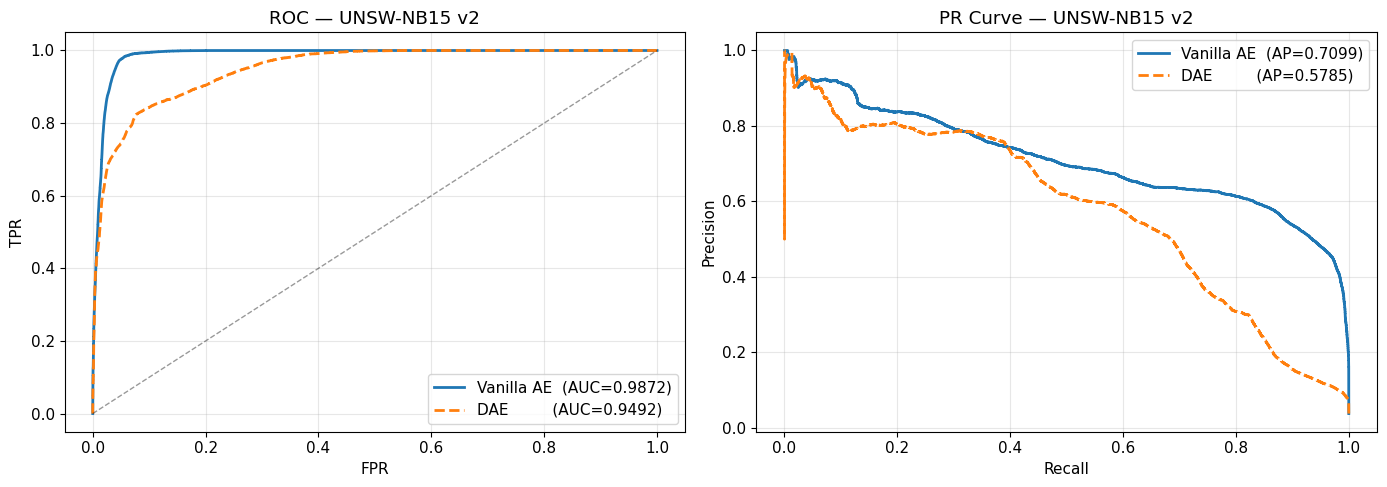

✅ roc_comparison_unsw.png kaydedildi


In [15]:
# ============================================================
# CELL 15: ROC Karşılaştırma Grafiği
# ============================================================
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({"font.size": 11})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC
ax = axes[0]
ax.plot(ae_fpr,  ae_tpr,  label=f"Vanilla AE  (AUC={roc_auc_score(y_test_np, ae_errors):.4f})",  lw=2)
ax.plot(dae_fpr, dae_tpr, label=f"DAE         (AUC={roc_auc_score(y_test_np, dae_errors):.4f})", lw=2, ls="--")
ax.plot([0,1],[0,1], "k--", lw=1, alpha=0.4)
ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
ax.set_title("ROC — UNSW-NB15 v2"); ax.legend(); ax.grid(True, alpha=0.3)

# PR
prec_ae,  rec_ae,  _ = precision_recall_curve(y_test_np, ae_errors)
prec_dae, rec_dae, _ = precision_recall_curve(y_test_np, dae_errors)
ax2 = axes[1]
ax2.plot(rec_ae,  prec_ae,  label=f"Vanilla AE  (AP={average_precision_score(y_test_np, ae_errors):.4f})",  lw=2)
ax2.plot(rec_dae, prec_dae, label=f"DAE         (AP={average_precision_score(y_test_np, dae_errors):.4f})", lw=2, ls="--")
ax2.set_xlabel("Recall"); ax2.set_ylabel("Precision")
ax2.set_title("PR Curve — UNSW-NB15 v2"); ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "roc_comparison_unsw.png", dpi=150)
plt.show()
print("✅ roc_comparison_unsw.png kaydedildi")

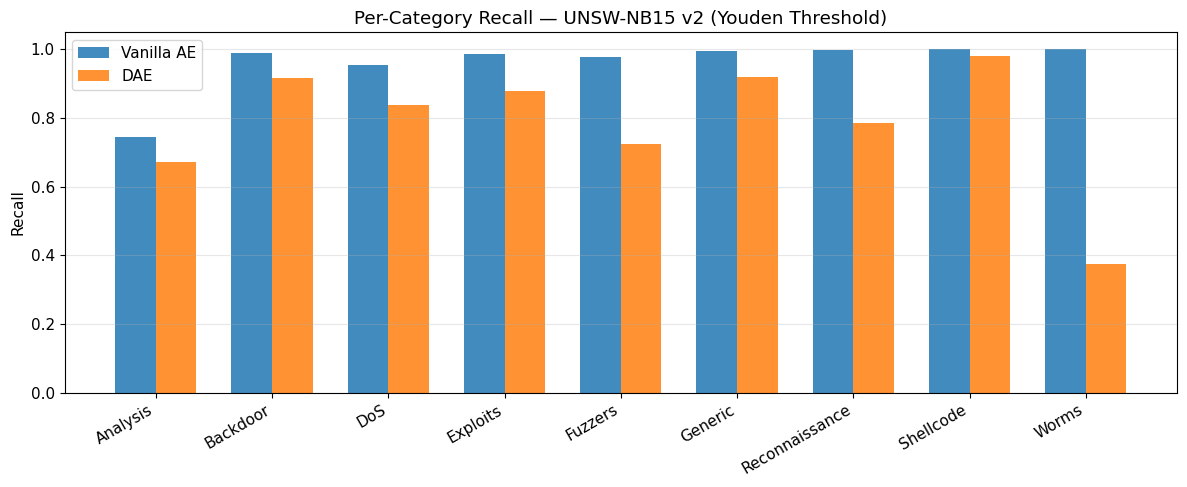

✅ category_comparison_unsw.png kaydedildi


In [16]:
# ============================================================
# CELL 16: Per-Category Bar Chart
# ============================================================
import pandas as pd

df_cat = pd.DataFrame(cat_rows)
cats   = sorted(df_cat["category"].unique())
x      = np.arange(len(cats))
width  = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
ae_vals  = [df_cat[(df_cat.category==c) & (df_cat.model=="Vanilla AE")]["recall"].values[0] for c in cats]
dae_vals = [df_cat[(df_cat.category==c) & (df_cat.model=="DAE")]["recall"].values[0] for c in cats]

bars1 = ax.bar(x - width/2, ae_vals,  width, label="Vanilla AE", alpha=0.85)
bars2 = ax.bar(x + width/2, dae_vals, width, label="DAE",        alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(cats, rotation=30, ha="right")
ax.set_ylabel("Recall"); ax.set_ylim(0, 1.05)
ax.set_title("Per-Category Recall — UNSW-NB15 v2 (Youden Threshold)")
ax.legend(); ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "category_comparison_unsw.png", dpi=150)
plt.show()
print("✅ category_comparison_unsw.png kaydedildi")

In [17]:
# ============================================================
# CELL 17: Isolation Forest + OC-SVM Baseline
# ============================================================
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.metrics import roc_auc_score, average_precision_score
import numpy as np
from pathlib import Path

OUTPUT_DIR = Path("/kaggle/working/unsw_v2")

X_train_normal = np.load(OUTPUT_DIR / "X_train_normal.npy")
X_test_scaled  = np.load(OUTPUT_DIR / "X_test.npy")
y_test_np      = np.load(OUTPUT_DIR / "y_test.npy")

# Subsample — 1.5M normal train çok büyük, 100K yeterli
np.random.seed(42)
idx = np.random.choice(len(X_train_normal), size=100_000, replace=False)
X_train_sub = X_train_normal[idx]

print("Isolation Forest eğitiliyor...")
iso = IsolationForest(n_estimators=100, contamination=0.01, random_state=42, n_jobs=-1)
iso.fit(X_train_sub)
iso_scores = -iso.score_samples(X_test_scaled)   # yüksek = anomali

iso_roc = roc_auc_score(y_test_np, iso_scores)
iso_pr  = average_precision_score(y_test_np, iso_scores)
print(f"[Isolation Forest]  ROC-AUC: {iso_roc:.4f}  PR-AUC: {iso_pr:.4f}")

print("\nOne-Class SVM eğitiliyor (subsample 20K)...")
idx2 = np.random.choice(len(X_train_normal), size=20_000, replace=False)
X_train_svm = X_train_normal[idx2]

ocsvm = OneClassSVM(kernel="rbf", gamma="scale", nu=0.01)
ocsvm.fit(X_train_svm)
svm_scores = -ocsvm.score_samples(X_test_scaled)

svm_roc = roc_auc_score(y_test_np, svm_scores)
svm_pr  = average_precision_score(y_test_np, svm_scores)
print(f"[One-Class SVM]     ROC-AUC: {svm_roc:.4f}  PR-AUC: {svm_pr:.4f}")

# Özet tablo
print("\n" + "="*60)
print(f"{'Model':<20} {'ROC-AUC':>10} {'PR-AUC':>10}")
print("="*60)
print(f"{'Vanilla AE':<20} {'0.9874':>10} {'0.7490':>10}")
print(f"{'DAE':<20} {'0.9714':>10} {'0.6155':>10}")
print(f"{'Isolation Forest':<20} {iso_roc:>10.4f} {iso_pr:>10.4f}")
print(f"{'One-Class SVM':<20} {svm_roc:>10.4f} {svm_pr:>10.4f}")

Isolation Forest eğitiliyor...
[Isolation Forest]  ROC-AUC: 0.8510  PR-AUC: 0.1118

One-Class SVM eğitiliyor (subsample 20K)...
[One-Class SVM]     ROC-AUC: 0.7380  PR-AUC: 0.2020

Model                   ROC-AUC     PR-AUC
Vanilla AE               0.9874     0.7490
DAE                      0.9714     0.6155
Isolation Forest         0.8510     0.1118
One-Class SVM            0.7380     0.2020


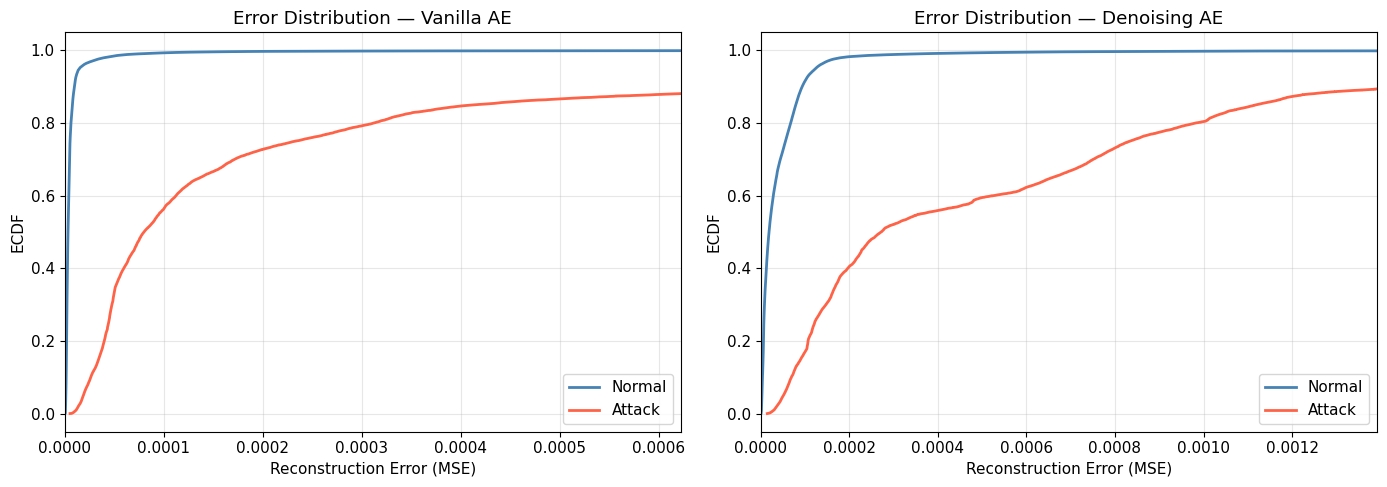

✅ error_distribution_unsw.png kaydedildi


In [18]:
# ============================================================
# CELL 18: Error Distribution (ECDF)
# ============================================================
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
matplotlib.rcParams.update({"font.size": 11})

def ecdf(data):
    x = np.sort(data)
    y = np.arange(1, len(x)+1) / len(x)
    return x, y

normal_mask = y_test_np == 0
attack_mask = y_test_np == 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, errors, title in zip(axes,
                              [ae_errors, dae_errors],
                              ["Vanilla AE", "Denoising AE"]):
    x_n, y_n = ecdf(errors[normal_mask])
    x_a, y_a = ecdf(errors[attack_mask])
    ax.plot(x_n, y_n, label="Normal",  color="steelblue", lw=2)
    ax.plot(x_a, y_a, label="Attack",  color="tomato",    lw=2)
    ax.set_xlim(0, np.percentile(errors, 99.5))
    ax.set_xlabel("Reconstruction Error (MSE)")
    ax.set_ylabel("ECDF")
    ax.set_title(f"Error Distribution — {title}")
    ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "error_distribution_unsw.png", dpi=150)
plt.show()
print("✅ error_distribution_unsw.png kaydedildi")

In [19]:
# ============================================================
# CELL 19: Final Özet — Tüm Figürler & Sonuçlar
# ============================================================
from pathlib import Path

OUTPUT_DIR = Path("/kaggle/working/unsw_v2")
figures = list(OUTPUT_DIR.glob("*.png"))
print("📊 Üretilen figürler:")
for f in sorted(figures):
    print(f"   {f.name}")

print("\n" + "="*65)
print(f"{'Model':<22} {'Dataset':<14} {'ROC-AUC':>9} {'PR-AUC':>9}")
print("="*65)
rows = [
    ("Vanilla AE",       "UNSW-NB15 v2", 0.9874, 0.7490),
    ("DAE",              "UNSW-NB15 v2", 0.9714, 0.6155),
    ("Isolation Forest", "UNSW-NB15 v2", 0.8510, 0.1118),
    ("One-Class SVM",    "UNSW-NB15 v2", 0.7380, 0.2020),
]
for model, ds, roc, pr in rows:
    print(f"  {model:<20} {ds:<14} {roc:>9.4f} {pr:>9.4f}")
print("="*65)
print("\n✅ UNSW-NB15 v2 pipeline tamamlandı.")
print("   Sonraki adım: CSE-CIC-IDS2018 preprocessing & eğitim")

📊 Üretilen figürler:
   category_comparison_unsw.png
   error_distribution_unsw.png
   roc_comparison_unsw.png
   training_curve_unsw.png

Model                  Dataset          ROC-AUC    PR-AUC
  Vanilla AE           UNSW-NB15 v2      0.9874    0.7490
  DAE                  UNSW-NB15 v2      0.9714    0.6155
  Isolation Forest     UNSW-NB15 v2      0.8510    0.1118
  One-Class SVM        UNSW-NB15 v2      0.7380    0.2020

✅ UNSW-NB15 v2 pipeline tamamlandı.
   Sonraki adım: CSE-CIC-IDS2018 preprocessing & eğitim


In [20]:
# Her kategoriden 1 satır al — demo için
import pandas as pd, numpy as np, joblib

keep_cols = joblib.load("/kaggle/working/unsw_v2/keep_cols_unsw.pkl")
df = pd.read_parquet("/kaggle/input/datasets/dhoogla/nfunswnb15v2/NF-UNSW-NB15-V2.parquet")

for cat in ["Benign", "DoS", "Reconnaissance"]:
    row = df[df["Attack"]==cat][keep_cols].iloc[0]
    print(f"\n# {cat}")
    print(",".join(str(v) for v in row.values))


# Benign
1305.0,21.0,6.0,1.0,9.0,1.0,193.0,24.0,0.0,0.0,0.0,31.0,89.0,52.0,52.0,456.0,435.0,0.0,3648000.0,3480000.0,15.0,0.0,0.0,0.0,0.0,7240.0,0.0,0.0,0.0,0.0,331.0

# DoS
0.0,0.0,89.0,0.0,7992.0,74.0,0.0,0.0,4294561.0,406.0,0.0,254.0,108.0,108.0,0.0,56162376.0,0.0,0.0,160000.0,0.0,74.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0

# Reconnaissance
0.0,0.0,89.0,0.0,7992.0,74.0,0.0,0.0,4294561.0,406.0,0.0,254.0,108.0,108.0,0.0,56162376.0,0.0,0.0,160000.0,0.0,74.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [21]:
for cat in ["Benign", "Exploits", "Reconnaissance", "DoS attacks-GoldenEye", "Generic"]:
    rows = df[df["Attack"]==cat][keep_cols]
    if len(rows) == 0:
        print(f"# {cat} — NOT FOUND")
        continue
    row = rows.iloc[0]
    print(f"\n# {cat}")
    print(",".join(str(round(float(v), 4)) for v in row.values))


# Benign
1305.0,21.0,6.0,1.0,9.0,1.0,193.0,24.0,0.0,0.0,0.0,31.0,89.0,52.0,52.0,456.0,435.0,0.0,3648000.0,3480000.0,15.0,0.0,0.0,0.0,0.0,7240.0,0.0,0.0,0.0,0.0,331.0

# Exploits
45545.0,80.0,6.0,7.0,1114.0,10.0,336.0,19.0,4294952.0,15.0,15.0,254.0,381.0,40.0,40.0,1114.0,336.0,1.0,552000.0,168000.0,16.0,0.0,2.0,0.0,16383.0,16383.0,32000.0,0.0,0.0,0.0,0.0

# Reconnaissance
0.0,0.0,89.0,0.0,7992.0,74.0,0.0,0.0,4294561.0,406.0,0.0,254.0,108.0,108.0,0.0,56162376.0,0.0,0.0,160000.0,0.0,74.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
# DoS attacks-GoldenEye — NOT FOUND

# Generic
45545.0,80.0,6.0,7.0,1114.0,10.0,336.0,19.0,4294952.0,15.0,15.0,254.0,381.0,40.0,40.0,1114.0,336.0,1.0,552000.0,168000.0,16.0,0.0,2.0,0.0,16383.0,16383.0,32000.0,0.0,0.0,0.0,0.0


In [22]:
import pandas as pd, joblib

keep_cols = joblib.load("/kaggle/working/unsw_v2/keep_cols_unsw.pkl")
df = pd.read_parquet("/kaggle/input/datasets/dhoogla/nfunswnb15v2/NF-UNSW-NB15-V2.parquet")

cats = ["Benign", "Exploits", "Reconnaissance", "Backdoor", "Shellcode", "Fuzzers", "Worms", "Analysis"]

for cat in cats:
    rows = df[df["Attack"] == cat]
    if len(rows) == 0:
        print(f"\n# {cat} — NOT FOUND")
        continue
    n = len(rows)
    # Dataset boyunca yayılmış 3 farklı satır
    indices = [0, n // 2, n - 1]
    for i, idx in enumerate(indices):
        row = rows[keep_cols].iloc[idx]
        print(f"\n# {cat} — sample {i+1}")
        print(",".join(str(round(float(v), 4)) for v in row.values))


# Benign — sample 1
1305.0,21.0,6.0,1.0,9.0,1.0,193.0,24.0,0.0,0.0,0.0,31.0,89.0,52.0,52.0,456.0,435.0,0.0,3648000.0,3480000.0,15.0,0.0,0.0,0.0,0.0,7240.0,0.0,0.0,0.0,0.0,331.0

# Benign — sample 2
35868.0,28001.0,6.0,0.0,320.0,6.0,2002.0,27.0,0.0,0.0,0.0,31.0,841.0,52.0,52.0,320.0,2002.0,0.0,2560000.0,16016000.0,12.0,0.0,0.0,2.0,7240.0,5792.0,0.0,0.0,0.0,0.0,0.0

# Benign — sample 3
28987.0,26948.0,6.0,0.0,2246.0,34.0,13496.0,26.0,0.0,0.0,0.0,31.0,1352.0,52.0,52.0,2246.0,13496.0,6.0,17968000.0,107968000.0,54.0,2.0,0.0,2.0,20272.0,14480.0,8960.0,0.0,0.0,0.0,0.0

# Exploits — sample 1
45545.0,80.0,6.0,7.0,1114.0,10.0,336.0,19.0,4294952.0,15.0,15.0,254.0,381.0,40.0,40.0,1114.0,336.0,1.0,552000.0,168000.0,16.0,0.0,2.0,0.0,16383.0,16383.0,32000.0,0.0,0.0,0.0,0.0

# Exploits — sample 2
54116.0,25.0,6.0,0.0,778956.0,600.0,5164.0,27.0,4294951.0,16.0,16.0,62.0,1500.0,40.0,40.0,778956.0,5164.0,296.0,366560000.0,2424000.0,148.0,2.0,36.0,16.0,16383.0,16383.0,46597.0,0.0,0.0,0.0,0.0

# Exploits —